# Model Evaluation

In [1]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import os

2026-04-21 17:24:02.326563: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 17:24:02.366945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 17:24:03.385190: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
sns.set_theme(style="darkgrid", context="paper", palette="bright")
plt.rcParams.update({
    "font.size":10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9

})

In [3]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [4]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
history = pd.read_csv(os.path.join(MODEL_DIR, "history.csv"))

X_test_scaled = np.load(os.path.join(ARTIFACT_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR, "y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR, "encoder.pkl"))

2026-04-21 17:24:03.994350: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
def plot_accuracy_and_loss(history):

    train_loss = history["loss"]
    val_loss = history["val_loss"]
    train_acc = history["accuracy"]
    val_acc = history["val_accuracy"]

    fig, ax = plt.subplots(1, 2, figsize=(7, 3))

    # Accuracy
    ax[0].plot(
        train_acc, label="Training", linewidth=1.5
    )
    ax[0].plot(
        val_acc, label="Validation", linewidth=1.5, linestyle="--"
    )
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].set_title("Accuracy")
    ax[0].grid(True, linestyle="--", alpha=0.5)
    ax[0].legend(frameon=True)

    # Loss
    ax[1].plot(
        train_acc, label="Training", linewidth=1.5
    )
    ax[1].plot(
        val_acc, label="Validation", linewidth=1.5, linestyle="--"
    )
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Loss")
    ax[1].grid(True, linestyle="--", alpha=0.5)
    ax[1].legend(frameon=True)


    plt.tight_layout()
    plt.savefig("LossAccCurves.png", format="png", dpi=300, bbox_inches="tight")
    plt.show()

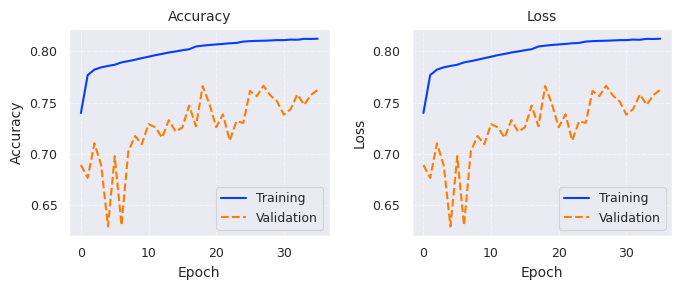

In [6]:
plot_accuracy_and_loss(history)

In [7]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step


In [21]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=classes,
        yticklabels=classes,
        cbar=False,
        square=True,
    )
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes, rotation=0)

    plt.tight_layout()
    plt.savefig("ConfusionMatrix.png", format="png", dpi=300, bbox_inches="tight")
    plt.show()

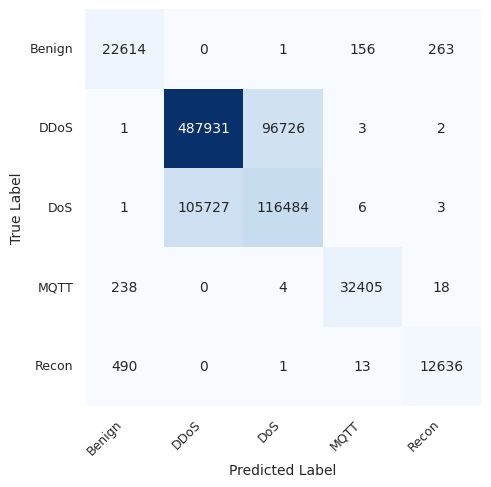

In [22]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [10]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9687    0.9818    0.9752     23034
        DDoS     0.8219    0.8346    0.8282    584663
         DoS     0.5463    0.5242    0.5350    222221
        MQTT     0.9945    0.9920    0.9933     32665
       Recon     0.9779    0.9616    0.9697     13140

    accuracy                         0.7674    875723
   macro avg     0.8619    0.8588    0.8603    875723
weighted avg     0.7646    0.7674    0.7659    875723



In [11]:
f1_score(y_test, y_pred_classes, average="macro")

0.8602759630907538

In [12]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 30s 1ms/step - accuracy: 0.7674 - loss: 0.4747
Test accuracy: 0.7674
